In [1]:
# Cell 1: Imports & plotting settings
# (Chạy trong Jupyter notebook)
%matplotlib inline
import os
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Load dữ liệu


In [2]:
# Cell 2: Load dataframe và chuẩn hoá tên cột (snake_case không dấu)
PATH = "../../.././data_thuydien/data_thuydien.csv"   # chỉnh đường dẫn nếu cần
df = pd.read_csv(PATH)
df.head()

,Tên hồ,Thời điểm,Mực nước thượng lưu (m),Mực nước dâng bình thường (m),Mực nước chết (m),Lưu lượng đến hồ (m3/s),Tổng lượng xả (m3/s),Tổng lượng xả qua đập tràn (m3/s),Tổng lượng xả qua nhà máy (m3/s),Số cửa xả sâu,Số cửa xả mặt
0,Hòa Bình,01/01/2022 00:00,112.13,117,80,848.0,1104.0,0.0,1104.0,0,0
1,Sông Ba Hạ,01/01/2022 00:00,104.94,105,101,410.0,450.0,50.0,400.0,0,1
2,Trị An,01/01/2022 00:00,61.29,62,50,170.0,0.0,0.0,0.0,0,0
3,Hòa Bình,01/01/2022 01:00,112.14,117,80,700.0,589.0,0.0,589.0,0,0
4,Sông Ba Hạ,01/01/2022 01:00,104.93,105,101,405.0,450.0,50.0,400.0,0,1


Xử lý tên tiếng việt


In [5]:
# Reload with utf-8-sig, normalize column names to snake_case (Vietnamese-aware), then parse thoi_diem
import pandas as pd, numpy as np, unicodedata, re, os
path = "../../.././data_thuydien/data_thuydien.csv"
df = pd.read_csv(path, dtype=str, encoding='utf-8-sig', low_memory=False)

# vn_to_snake (robust to leading/trailing spaces and BOM)
def vn_to_snake(s: str) -> str:
    s = str(s).strip()
    s_norm = unicodedata.normalize('NFD', s)
    s_no_accents = ''.join(ch for ch in s_norm if unicodedata.category(ch) != 'Mn')
    s_no_accents = s_no_accents.replace('đ', 'd').replace('Đ', 'D')
    s_snake = re.sub(r'[^a-zA-Z0-9]+', '_', s_no_accents).lower().strip('_')
    if re.match(r'^\d', s_snake or ''):
        s_snake = 'c_' + s_snake
    return s_snake or 'col'

orig_cols = list(df.columns)
new_cols = [vn_to_snake(c) for c in orig_cols]
col_map = dict(zip(orig_cols, new_cols))
df.rename(columns=col_map, inplace=True)
print("Renamed columns (sample):")
for o,n in list(col_map.items())[:10]:
    print(f"  {o!r} -> {n!r}")

# Which column corresponds to 'thoi_diem' after renaming?
print("\\nAll columns after rename (first 20):", list(df.columns)[:20])

# If thoi_diem exists, parse it using the robust parser from before
if 'thoi_diem' in df.columns:
    # preserve raw
    df['thoi_diem_raw'] = df['thoi_diem']
    # reuse previous parsing function (simpler)
    import unicodedata, re
    def _clean_vi_datetime(s):
        if pd.isna(s): return np.nan
        s = str(s).strip()
        if not s: return np.nan
        s = unicodedata.normalize('NFKC', s)
        s = s.replace('\u2013','-').replace('\u2014','-')
        s = re.sub(r'\s+', ' ', s)
        s = re.sub(r'\b(ict|gmt\+?7|utc\+?7|vn)\b', '', s, flags=re.I).strip()
        s = re.sub(r'(?i)\b(thg|thang|tháng)\s*(\d{1,2})\b', r'\2', s)
        s = re.sub(r'(?i)\bngay\b', '', s)
        s = re.sub(r'(?i)\bgio\b', ':', s)
        s = re.sub(r'(?i)\bphut\b', '', s)
        s = s.replace('h', ':')
        s = s.replace('.', '/').replace('-', '/')
        s = re.sub(r'(\d{1,2})\s*/\s*(\d{1,2})\s*/\s*(\d{2,4})', r'\1/\2/\3', s)
        s = re.sub(r'(\b\d{1,2})[:h](\d{1,2})([:](\d{1,2}))?', 
                   lambda m: f"{int(m.group(1)):02d}:{int(m.group(2)):02d}" + (f":{int(m.group(4)):02d}" if m.group(4) else ""), s)
        s = re.sub(r'\s+', ' ', s).strip()
        return s or np.nan
    def parse_series_vi_dt(series):
        cleaned = series.map(_clean_vi_datetime)
        dt = pd.to_datetime(cleaned, errors='coerce', dayfirst=True)
        mask_24 = cleaned.str.contains(r'\b24:00(?::00)?\b', na=False)
        if mask_24.any():
            fix24 = cleaned[mask_24].str.replace('24:00', '00:00', regex=False)
            dt.loc[mask_24] = pd.to_datetime(fix24, errors='coerce', dayfirst=True) + pd.Timedelta(days=1)
        # Excel / epoch / compact handled if needed (skipped for speed)
        return dt, cleaned
    dt, cleaned = parse_series_vi_dt(df['thoi_diem_raw'])
    df['thoi_diem_cleaned_txt'] = cleaned
    df['thoi_diem'] = dt
    # Summary and examples
    n = len(df)
    parsed = df['thoi_diem'].notna().sum()
    nat = n - parsed
    print(f"Rows: {n}, Parsed OK: {parsed}, NaT remaining: {nat}")
    # show head and problematic samples
    display(df.head(10))
    if nat>0:
        print("\\nCác mẫu còn NaT (tối đa 20):")
        display(df.loc[df['thoi_diem'].isna(), ['thoi_diem_raw','thoi_diem_cleaned_txt']].head(20))
    # Save cleaned file
    out_path = "../../.././data_thuydien/data_thuydien_noneVietnamese.csv"
    df.to_csv(out_path, index=False)
    print("\\nSaved cleaned CSV to:", out_path)
else:
    print("Sau khi rename, không tìm thấy cột 'thoi_diem'. Các cột hiện có:", list(df.columns)[:50])

df.head()

Renamed columns (sample):
  'Tên hồ' -> 'ten_ho'
  'Thời điểm' -> 'thoi_diem'
  'Mực nước  thượng lưu (m)' -> 'muc_nuoc_thuong_luu_m'
  'Mực nước  dâng bình thường (m)' -> 'muc_nuoc_dang_binh_thuong_m'
  'Mực nước  chết (m)' -> 'muc_nuoc_chet_m'
  'Lưu lượng  đến hồ  (m3/s)' -> 'luu_luong_den_ho_m3_s'
  'Tổng lượng xả  (m3/s)' -> 'tong_luong_xa_m3_s'
  'Tổng lượng xả  qua đập  tràn (m3/s)' -> 'tong_luong_xa_qua_dap_tran_m3_s'
  'Tổng lượng xả  qua nhà  máy (m3/s)' -> 'tong_luong_xa_qua_nha_may_m3_s'
  'Số cửa  xả sâu' -> 'so_cua_xa_sau'
\nAll columns after rename (first 20): ['ten_ho', 'thoi_diem', 'muc_nuoc_thuong_luu_m', 'muc_nuoc_dang_binh_thuong_m', 'muc_nuoc_chet_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'so_cua_xa_sau', 'so_cua_xa_mat']
Rows: 103029, Parsed OK: 103029, NaT remaining: 0


,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat,thoi_diem_raw,thoi_diem_cleaned_txt
0,Hòa Bình,2022-01-01 00:00:00,112.13,117,80,848,1104,0,1104,0,0,01/01/2022 00:00,01/01/2022 00:00
1,Sông Ba Hạ,2022-01-01 00:00:00,104.94,105,101,410,450,50,400,0,1,01/01/2022 00:00,01/01/2022 00:00
2,Trị An,2022-01-01 00:00:00,61.29,62,50,170,0,0,0,0,0,01/01/2022 00:00,01/01/2022 00:00
3,Hòa Bình,2022-01-01 01:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 01:00,01/01/2022 01:00
4,Sông Ba Hạ,2022-01-01 01:00:00,104.93,105,101,405,450,50,400,0,1,01/01/2022 01:00,01/01/2022 01:00
5,Trị An,2022-01-01 01:00:00,61.3,62,50,210,0,0,0,0,0,01/01/2022 01:00,01/01/2022 01:00
6,Hòa Bình,2022-01-01 02:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 02:00,01/01/2022 02:00
7,Sông Ba Hạ,2022-01-01 02:00:00,104.93,105,101,415,450,50,400,0,1,01/01/2022 02:00,01/01/2022 02:00
8,Trị An,2022-01-01 02:00:00,61.3,62,50,210,0,0,0,0,0,01/01/2022 02:00,01/01/2022 02:00
9,Hòa Bình,2022-01-01 03:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 03:00,01/01/2022 03:00


\nSaved cleaned CSV to: ../../.././data_thuydien/data_thuydien_noneVietnamese.csv


,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat,thoi_diem_raw,thoi_diem_cleaned_txt
0,Hòa Bình,2022-01-01 00:00:00,112.13,117,80,848,1104,0,1104,0,0,01/01/2022 00:00,01/01/2022 00:00
1,Sông Ba Hạ,2022-01-01 00:00:00,104.94,105,101,410,450,50,400,0,1,01/01/2022 00:00,01/01/2022 00:00
2,Trị An,2022-01-01 00:00:00,61.29,62,50,170,0,0,0,0,0,01/01/2022 00:00,01/01/2022 00:00
3,Hòa Bình,2022-01-01 01:00:00,112.14,117,80,700,589,0,589,0,0,01/01/2022 01:00,01/01/2022 01:00
4,Sông Ba Hạ,2022-01-01 01:00:00,104.93,105,101,405,450,50,400,0,1,01/01/2022 01:00,01/01/2022 01:00


In [6]:
df = df.drop(columns=['thoi_diem_raw', 'thoi_diem_cleaned_txt'], errors='ignore')
df.to_csv(out_path, index=False)

# Thống kê đơn biến


In [4]:
# Tạo bảng thống kê mở rộng cho các cột numeric được chỉ định và hiển thị kết quả.
import pandas as pd, numpy as np
path = "../../.././data_thuydien/dataCacDap/data_thuydien_Sông_Ba_Hạ.csv"
df = pd.read_csv(path, low_memory=False)

cols_target = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s"    
]

# Kiểm tra tồn tại cột
missing_cols = [c for c in cols_target if c not in df.columns]
if missing_cols:
    raise KeyError(f"Các cột sau không tồn tại trong file: {missing_cols}")

# Chuyển sang numeric (nếu có chuỗi), giữ bản gốc để truy vết
df_num = df[cols_target].apply(pd.to_numeric, errors='coerce')

def extended_stats(series: pd.Series):
    s = series.dropna()
    vc = s.value_counts()
    top = vc.index[0] if not vc.empty else np.nan
    freq = int(vc.iloc[0]) if not vc.empty else 0
    return {
        'count': int(series.count()),
        'missing': int(series.isna().sum()),
        'unique': int(series.nunique(dropna=True)),
        'top': top,
        'freq': freq,
        'mean': float(series.mean()) if series.count()>0 else np.nan,
        'std': float(series.std(ddof=1)) if series.count()>1 else np.nan,
        'min': float(series.min()) if series.count()>0 else np.nan,
        '25%': float(series.quantile(0.25)) if series.count()>0 else np.nan,
        '50%': float(series.quantile(0.5)) if series.count()>0 else np.nan,
        '75%': float(series.quantile(0.75)) if series.count()>0 else np.nan,
        'max': float(series.max()) if series.count()>0 else np.nan,
        'skew': float(series.skew()) if series.count()>2 else np.nan,
        'kurtosis': float(series.kurt()) if series.count()>3 else np.nan
    }

rows = {c: extended_stats(df_num[c]) for c in cols_target}
summary_df = pd.DataFrame.from_dict(rows, orient='index')[
    ['count','missing','unique','top','freq','mean','std','min','25%','50%','75%','max','skew','kurtosis']
]

# Hiển thị cả describe() mặc định để so sánh
display("Pandas describe() (numeric):")
display(df_num.describe().T)

display("Bảng thống kê mở rộng (bao gồm top/freq):")
display(summary_df)

# Lưu ra CSV tạm nếu người dùng muốn tải
out_path = ".././ThongKeDonBien/SongBaHa/numeric_stats_extended.csv"
summary_df.to_csv(out_path)
print("Saved extended stats to:", out_path)



'Pandas describe() (numeric):'

,count,mean,std,min,25%,50%,75%,max
muc_nuoc_thuong_luu_m,34343.0,103.350266,1.640459,2.68,102.71,103.31,104.26,105.96
luu_luong_den_ho_m3_s,34343.0,227.474201,570.179640,0.00,45.00,100.00,250.00,16160.00
tong_luong_xa_m3_s,34343.0,224.794374,546.091014,0.00,0.00,120.00,389.00,16100.00
tong_luong_xa_qua_dap_tran_m3_s,34342.0,68.517442,499.557011,0.00,0.00,0.00,0.00,16100.00
tong_luong_xa_qua_nha_may_m3_s,34342.0,156.283478,166.243586,0.00,0.00,120.00,378.00,410.00


'Bảng thống kê mở rộng (bao gồm top/freq):'

,count,missing,unique,top,freq,mean,std,min,25%,50%,75%,max,skew,kurtosis
muc_nuoc_thuong_luu_m,34343,0,448,102.93,482,103.350266,1.640459,2.68,102.71,103.31,104.26,105.96,-30.603611,1542.151894
luu_luong_den_ho_m3_s,34343,0,845,40.00,1482,227.474201,570.179640,0.00,45.00,100.00,250.00,16160.00,15.765918,345.324335
tong_luong_xa_m3_s,34343,0,460,0.00,15317,224.794374,546.091014,0.00,0.00,120.00,389.00,16100.00,15.006166,334.811725
tong_luong_xa_qua_dap_tran_m3_s,34342,1,102,0.00,27993,68.517442,499.557011,0.00,0.00,0.00,0.00,16100.00,19.459637,484.707754
tong_luong_xa_qua_nha_may_m3_s,34342,1,228,0.00,15355,156.283478,166.243586,0.00,0.00,120.00,378.00,410.00,0.469348,-1.448231


Saved extended stats to: .././ThongKeDonBien/SongBaHa/numeric_stats_extended.csv


# Trực quan hoá đơn biến


In [5]:
# Cell 3: Danh sách biến liên tục cần phân tích và chuyển về numeric an toàn
cols_target = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s"    
]

present = [c for c in cols_target if c in df.columns]
missing = [c for c in cols_target if c not in df.columns]
print("Có trong dataset:", present)
if missing:
    print("Không tìm thấy (bỏ qua):", missing)

out_dir = ".././TrucQuanDonBien/SongBaHa"

Có trong dataset: ['muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s']


muc_nuoc_thuong_luu_m IQR bounds: LB=100.38, UB=106.59
Full n=34,343 | Inlier n=34,333 | Outlier n=10


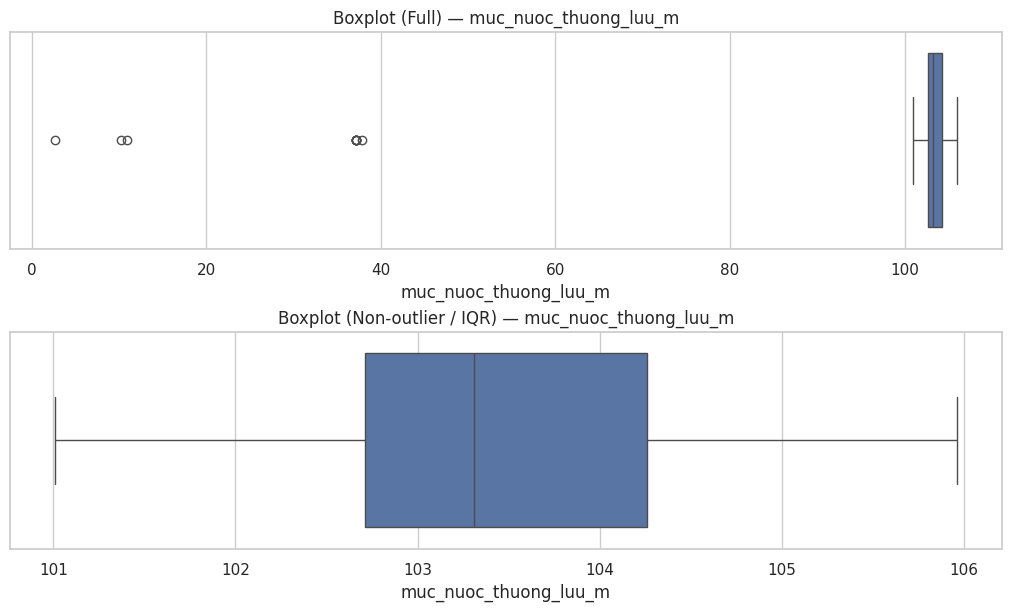

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_boxplot_full_and_inlier.png


In [7]:
# =============================
# Boxplot full + boxplot non-outlier (IQR)
# =============================
c = "muc_nuoc_thuong_luu_m"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    # --- IQR bounds ---
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # Non-outlier series
    s_inlier = s[(s >= LB) & (s <= UB)]

    print(f"{c} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(s):,} | Inlier n={len(s_inlier):,} | Outlier n={(len(s)-len(s_inlier)):,}")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Boxplot (full)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot (Full) — {c}")
    axes[0].set_xlabel(c)

    # Boxplot (non-outlier)
    sns.boxplot(x=s_inlier, ax=axes[1])
    axes[1].set_title(f"Boxplot (Non-outlier / IQR) — {c}")
    axes[1].set_xlabel(c)

    # Save & show
    fn = os.path.join(out_dir, f"{c}_boxplot_full_and_inlier.png")
    fig.savefig(fn, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")


luu_luong_den_ho_m3_s IQR bounds: LB=-262.50, UB=557.50
Full n=34,343 | Inlier n=31,803 | Outlier n=2,540


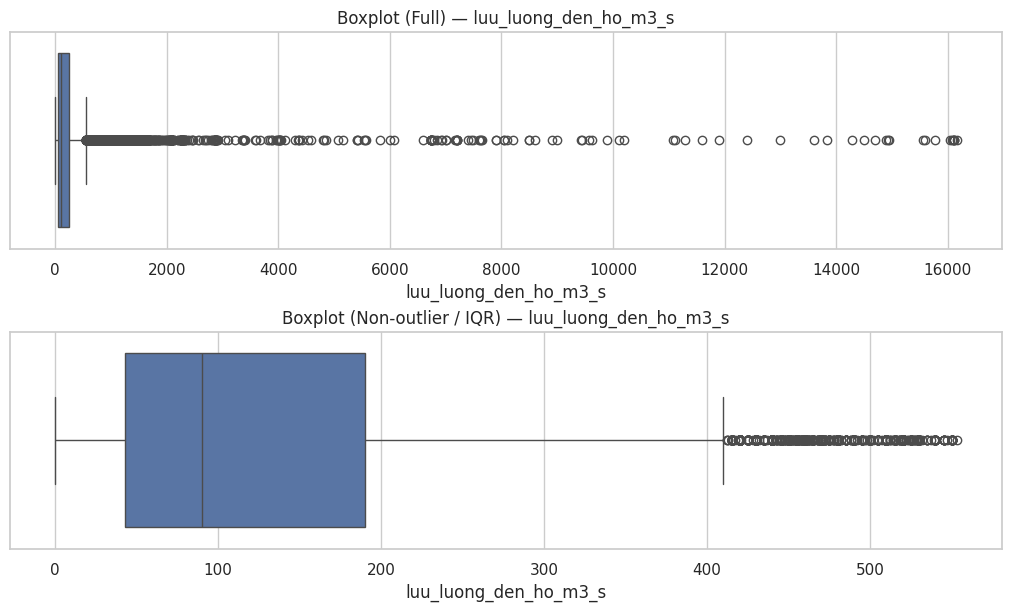

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_boxplot_full_and_inlier.png


In [8]:
c = "luu_luong_den_ho_m3_s"
# =============================
# Boxplot full + boxplot non-outlier (IQR)
# =============================
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    # --- IQR bounds ---
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # Non-outlier series
    s_inlier = s[(s >= LB) & (s <= UB)]

    print(f"{c} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(s):,} | Inlier n={len(s_inlier):,} | Outlier n={(len(s)-len(s_inlier)):,}")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Boxplot (full)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot (Full) — {c}")
    axes[0].set_xlabel(c)

    # Boxplot (non-outlier)
    sns.boxplot(x=s_inlier, ax=axes[1])
    axes[1].set_title(f"Boxplot (Non-outlier / IQR) — {c}")
    axes[1].set_xlabel(c)

    # Save & show
    fn = os.path.join(out_dir, f"{c}_boxplot_full_and_inlier.png")
    fig.savefig(fn, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")


tong_luong_xa_m3_s IQR bounds: LB=-583.50, UB=972.50
Full n=34,343 | Inlier n=33,507 | Outlier n=836


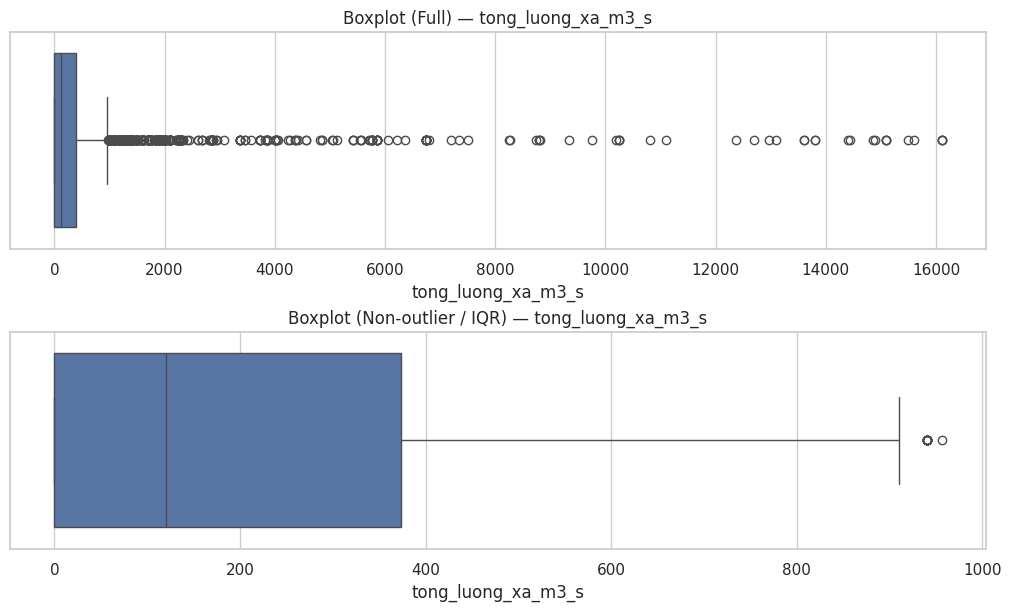

Saved: .././TrucQuanDonBien/SongBaHa/tong_luong_xa_m3_s_boxplot_full_and_inlier.png


In [10]:
c = "tong_luong_xa_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    # --- IQR bounds ---
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # Non-outlier series
    s_inlier = s[(s >= LB) & (s <= UB)]

    print(f"{c} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(s):,} | Inlier n={len(s_inlier):,} | Outlier n={(len(s)-len(s_inlier)):,}")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Boxplot (full)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot (Full) — {c}")
    axes[0].set_xlabel(c)

    # Boxplot (non-outlier)
    sns.boxplot(x=s_inlier, ax=axes[1])
    axes[1].set_title(f"Boxplot (Non-outlier / IQR) — {c}")
    axes[1].set_xlabel(c)

    # Save & show
    fn = os.path.join(out_dir, f"{c}_boxplot_full_and_inlier.png")
    fig.savefig(fn, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

"tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s"  

tong_luong_xa_qua_dap_tran_m3_s IQR bounds: LB=0.00, UB=0.00
Full n=34,342 | Inlier n=27,993 | Outlier n=6,349


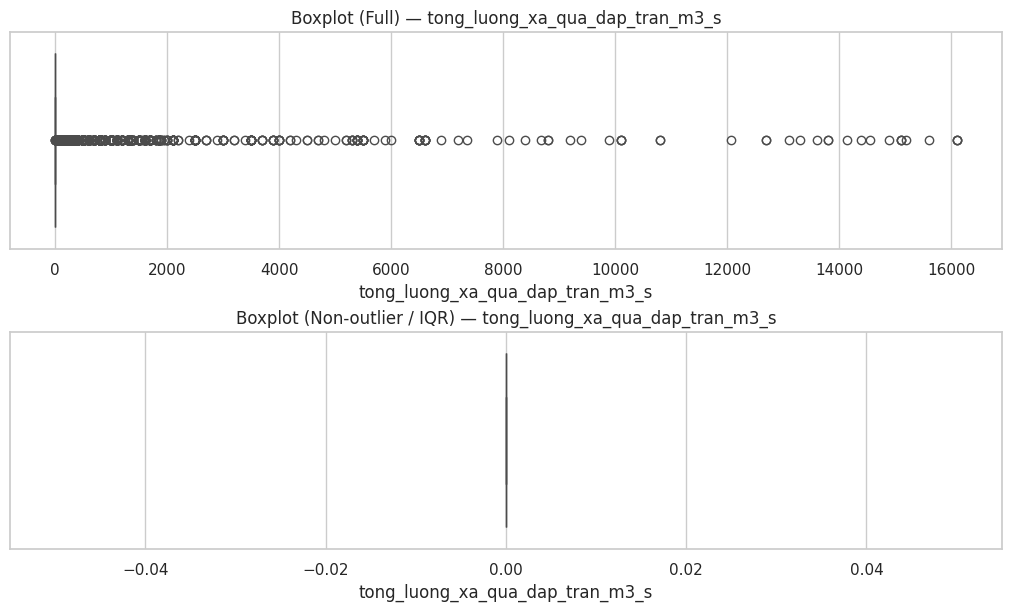

Saved: .././TrucQuanDonBien/SongBaHa/tong_luong_xa_qua_dap_tran_m3_s_boxplot_full_and_inlier.png


In [12]:
c = "tong_luong_xa_qua_dap_tran_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    # --- IQR bounds ---
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # Non-outlier series
    s_inlier = s[(s >= LB) & (s <= UB)]

    print(f"{c} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(s):,} | Inlier n={len(s_inlier):,} | Outlier n={(len(s)-len(s_inlier)):,}")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # Boxplot (full)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot (Full) — {c}")
    axes[0].set_xlabel(c)

    # Boxplot (non-outlier)
    sns.boxplot(x=s_inlier, ax=axes[1])
    axes[1].set_title(f"Boxplot (Non-outlier / IQR) — {c}")
    axes[1].set_xlabel(c)

    # Save & show
    fn = os.path.join(out_dir, f"{c}_boxplot_full_and_inlier.png")
    fig.savefig(fn, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

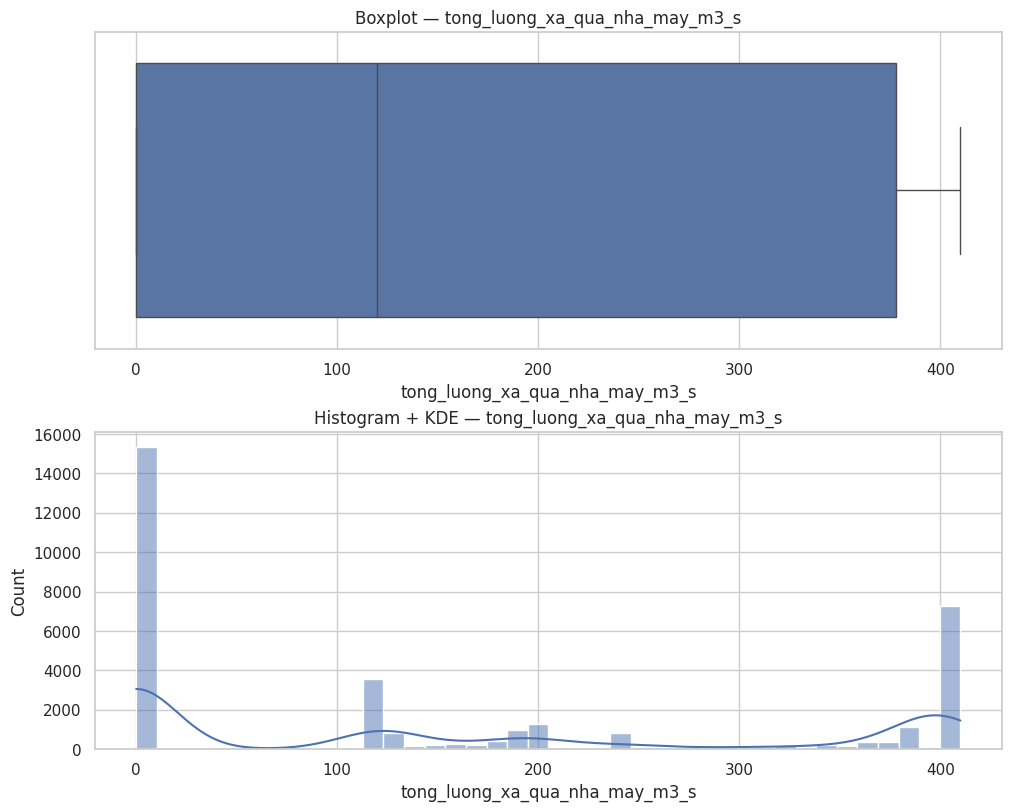

Saved: .././TrucQuanDonBien/SongBaHa/tong_luong_xa_qua_nha_may_m3_s_box_hist.png


In [14]:
c = "tong_luong_xa_qua_nha_may_m3_s"
s = df[c].dropna().astype(float)

if s.empty:
    print(f"{c}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

    # Boxplot (hàng trên)
    sns.boxplot(x=s, ax=axes[0])
    axes[0].set_title(f"Boxplot — {c}")
    axes[0].set_xlabel(c)

    # Histogram + KDE (hàng dưới)
    sns.histplot(s, bins=40, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram + KDE — {c}")
    axes[1].set_xlabel(c)
    axes[1].set_ylabel("Count")

    # Lưu và hiển thị
    fn = os.path.join(out_dir, f"{c}_box_hist.png")
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved: {fn}")

# Trực quan đa biến


## Cái này thiên hướng thống kê


('.././TrucQuanDaBien/SongBaHa/pairplot_sample.png',
 '.././TrucQuanDaBien/SongBaHa/correlation_heatmap.png')

<Figure size 1200x1200 with 0 Axes>

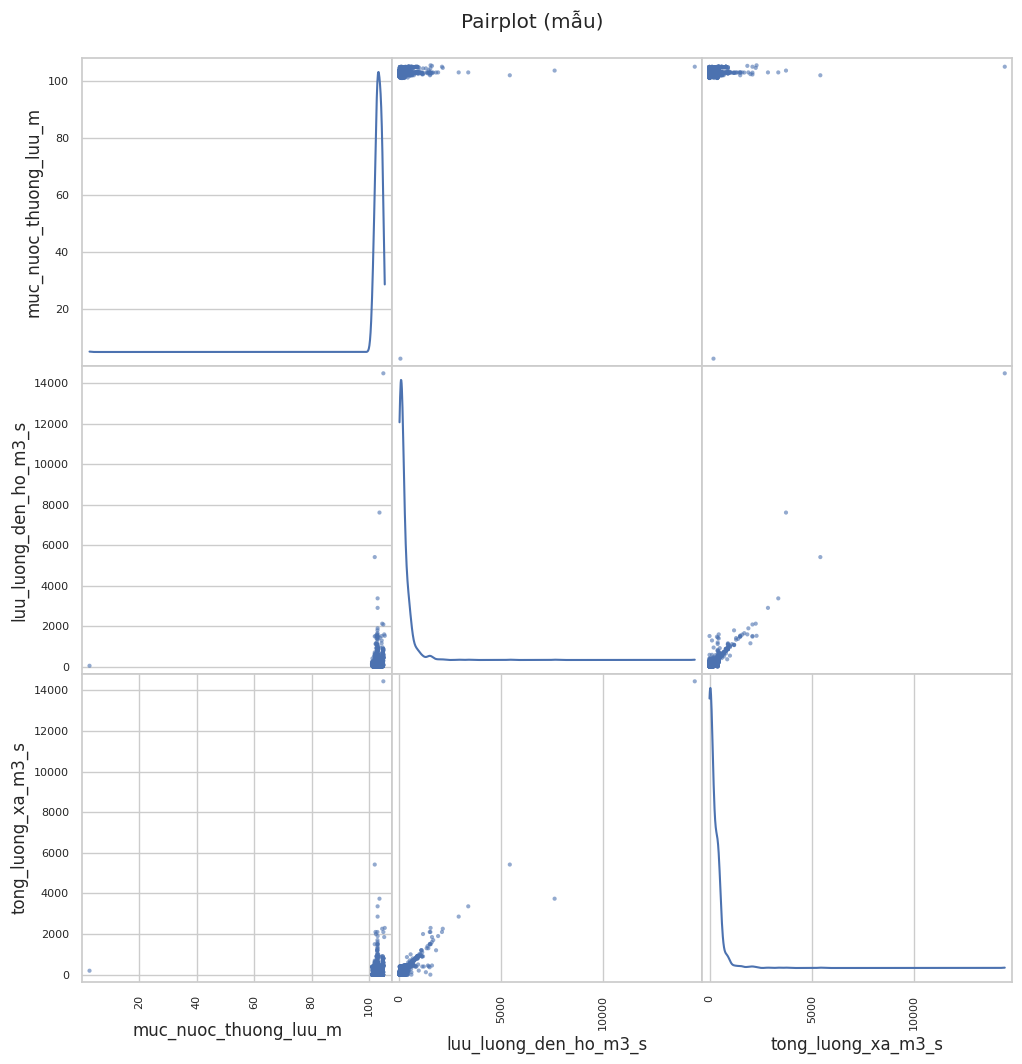

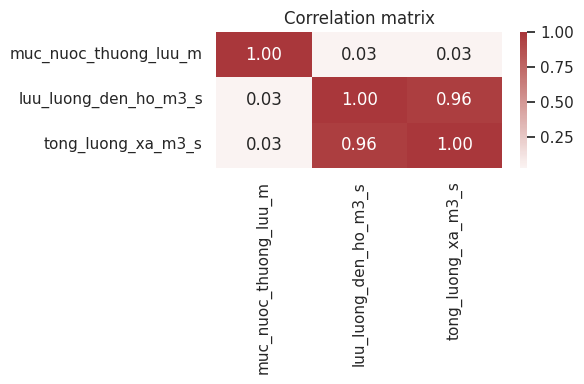

In [15]:
# Create and save pairplot equivalent using pandas.scatter_matrix and correlation heatmap
import os, re, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

OUT_DIR = ".././TrucQuanDaBien/SongBaHa"
os.makedirs(OUT_DIR, exist_ok=True)

paths = ["../../.././data_thuydien/dataCacDap/data_thuydien_Sông_Ba_Hạ.csv"]
df = None
for p in paths:
    try:
        df = pd.read_csv(p)
        break
    except Exception:
        df = None

if df is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu.")

def vn_to_snake(s: str) -> str:
    s = str(s).strip()
    s_norm = unicodedata.normalize('NFD', s)
    s_no_accents = ''.join(ch for ch in s_norm if unicodedata.category(ch) != 'Mn')
    s_no_accents = s_no_accents.replace('đ', 'd').replace('Đ', 'D')
    s_snake = re.sub(r'[^a-zA-Z0-9]+', '_', s_no_accents).lower().strip('_')
    if s_snake and s_snake[0].isdigit():
        s_snake = 'c_' + s_snake
    return s_snake or 'col'

df.rename(columns={c: vn_to_snake(c) for c in df.columns}, inplace=True)

present = [
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s"
]
present = [c for c in present if c in df.columns]

# convert to numeric safely by removing commas/spaces
for c in present:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

if len(present) >= 2:
    base = df[present].dropna()
    sample_n = min(1500, base.shape[0])
    sample = base.sample(n=sample_n, random_state=42)
    # scatter_matrix as pairplot equivalent
    fig = plt.figure(figsize=(12,12))
    axes = scatter_matrix(sample, diagonal='kde', alpha=0.6, figsize=(12,12))
    plt.suptitle("Pairplot (mẫu)", y=0.92)
    pairplot_path = os.path.join(OUT_DIR, "pairplot_sample.png")
    fig.savefig(pairplot_path, bbox_inches='tight', dpi=150)
else:
    raise ValueError("Không đủ 2 biến để vẽ.")

# Correlation heatmap
if len(present) >= 2:
    # Correlation heatmap
    corr = df[present].corr()
    fig2, ax2 = plt.subplots(figsize=(6,4))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax2)
    ax2.set_title("Correlation matrix")
    plt.tight_layout()
    heatmap_path = os.path.join(OUT_DIR, "correlation_heatmap.png")
    fig2.savefig(heatmap_path, bbox_inches='tight', dpi=150)
else:
    raise ValueError("Không đủ 2 biến để vẽ ma trận tương quan.")

pairplot_path, heatmap_path



## Trực quan hoá đa biến theo từng cặp


### Load dữ liệu


In [16]:
df = pd.read_csv("../../.././data_thuydien/dataCacDap/data_thuydien_Sông_Ba_Hạ.csv")

cols_target = [
    "thoi_diem",
    "muc_nuoc_thuong_luu_m",
    "luu_luong_den_ho_m3_s",
    "tong_luong_xa_m3_s",
    "tong_luong_xa_qua_dap_tran_m3_s",
    "tong_luong_xa_qua_nha_may_m3_s" 
]

df[cols_target]

,thoi_diem,muc_nuoc_thuong_luu_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s
0,2022-01-01 00:00:00,104.94,410.0,450.0,50.0,400.0
1,2022-01-01 01:00:00,104.93,405.0,450.0,50.0,400.0
2,2022-01-01 02:00:00,104.93,415.0,450.0,50.0,400.0
3,2022-01-01 03:00:00,104.92,420.0,450.0,50.0,400.0
4,2022-01-01 04:00:00,104.92,425.0,450.0,50.0,400.0
...,...,...,...,...,...,...
34338,2025-12-01 19:00:00,101.98,460.0,460.0,78.0,382.0
34339,2025-12-01 20:00:00,101.98,470.0,460.0,78.0,382.0
34340,2025-12-01 21:00:00,101.98,480.0,460.0,78.0,382.0
34341,2025-12-01 22:00:00,101.99,480.0,460.0,78.0,382.0


### Mực nước thượng lưu (m) trên từng thời điểm


In [17]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'muc_nuoc_thuong_luu_m'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

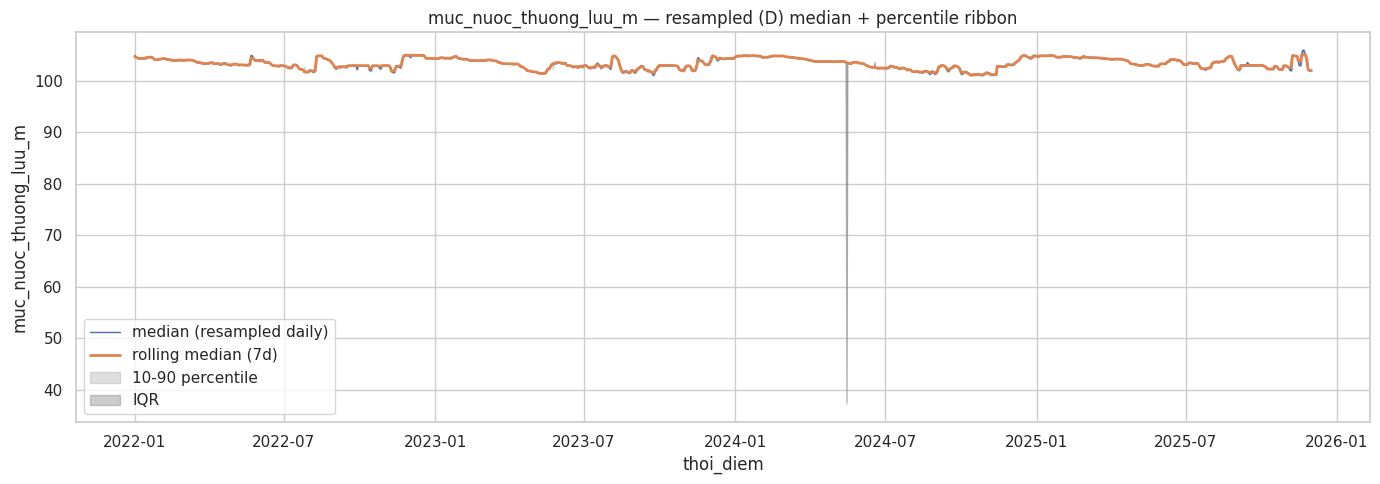

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_resampled_trend_daily.png


In [18]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = ".././TrucQuanDaBien/SongBaHa"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


Giải thích 4 kí hiệu trong đồ thị (trong bối cảnh dự báo **mực nước thượng lưu**)

> Dữ liệu mỗi ngày có ~8 quan sát (02h, 05h, …, 23h). Việc **resample theo ngày (‘D’)** gom các điểm trong cùng một ngày để tính thống kê tổng hợp.

---
1. **median (resampled daily)**
- **Định nghĩa:** Trung vị của **mực nước thượng lưu** trong **một ngày**, sau khi gom tất cả các quan sát của ngày đó.  
- **Ý nghĩa:** Đại diện cho “mực nước điển hình nhất trong ngày”, ít bị ảnh hưởng bởi các giá trị bất thường (spike, lỗi đo).  
- **Cách đọc:** Đường mảnh biểu diễn **xu hướng trung tâm** theo ngày.  
- **Ứng dụng làm feature:**  
  - `level_median_D`: trung vị theo ngày.  
  - Biến thể: `delta_median_D = median_D - median_{D-1}`, hoặc rolling statistics.  
  - Dùng làm đại diện cho nền mực nước ổn định trước khi dự báo.

---

2. **rolling median (7 ngày)**
- **Định nghĩa:** Trung vị trượt trên chuỗi `median` theo cửa sổ **7 ngày** (`center=True` → trung tâm cửa sổ đối xứng).  
- **Ý nghĩa:** Làm mượt xu thế trung hạn (1 tuần) của mực nước, tách **xu hướng dài hạn** khỏi **dao động nhanh trong ngày**.  
- **Cách đọc:** Đường dày, mượt hơn median daily → thể hiện **trend** chậm.  
- **Ứng dụng làm feature:**  
  - `trend_7d = rolling_median_7d(median_D)`  
  - `gap_to_trend = median_D - trend_7d`  
  - Khi dự báo tương lai, tránh rò rỉ dữ liệu bằng cách dùng **rolling trailing** (`center=False`).

---

3. **10–90 percentile (ribbon)**
- **Định nghĩa:** Với mỗi ngày, tính phân vị **P10** và **P90** của các quan sát trong ngày.  
- **Ý nghĩa:** Khoảng dao động chứa ~80% dữ liệu nội ngày → thể hiện **độ biến động tổng thể**.  
  - Dải rộng → biến động mạnh (mưa lớn, vận hành điều tiết).  
  - Dải hẹp → ngày ổn định.  
- **Cách đọc:** Vùng xám nhạt (P10–P90) trên đồ thị.  
- **Ứng dụng làm feature:**  
  - `range_p90_p10 = p90 - p10`  
  - `rel_range = (p90 - p10) / median_D`  
  - Dùng để mô tả **volatility** – hữu ích khi dự báo các biến động đột ngột.

---

4. **IQR (Inter-Quartile Range: P75–P25)**
- **Định nghĩa:** Khoảng tứ phân vị (P75 – P25), bao gồm **50% giá trị trung tâm** trong ngày.  
- **Ý nghĩa:** Thước đo độ phân tán điển hình, bền vững với nhiễu.  
  - IQR cao → mực nước nội ngày biến động mạnh.  
  - IQR thấp → mực nước ổn định.  
- **Cách đọc:** Vùng xám đậm (nằm trong P10–P90).  
- **Ứng dụng làm feature:**  
  - `iqr = p75 - p25`  
  - `rel_iqr = iqr / median_D`  
  - Hữu ích để phát hiện **thay đổi trạng thái vận hành**.


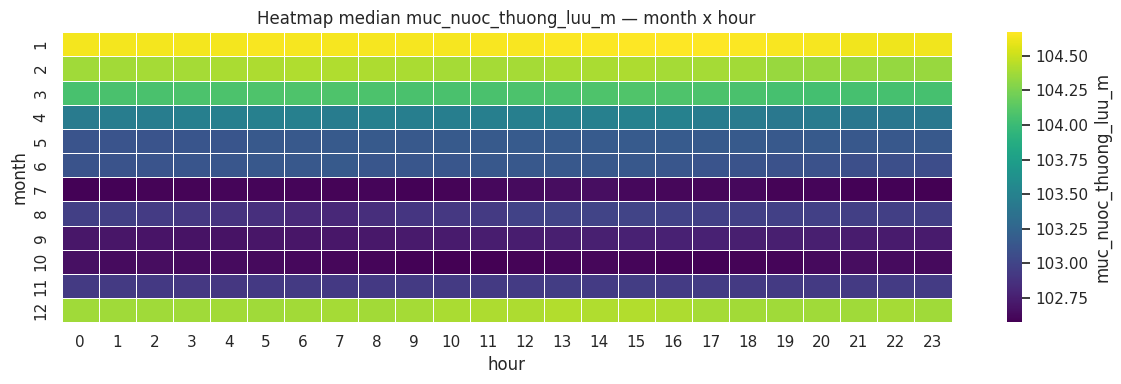

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_month_hour_heatmap.png


In [19]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


muc_nuoc_thuong_luu_m IQR bounds: LB=100.38, UB=106.59
Full n=34,343 | Inlier n=34,333 | Outlier n=10


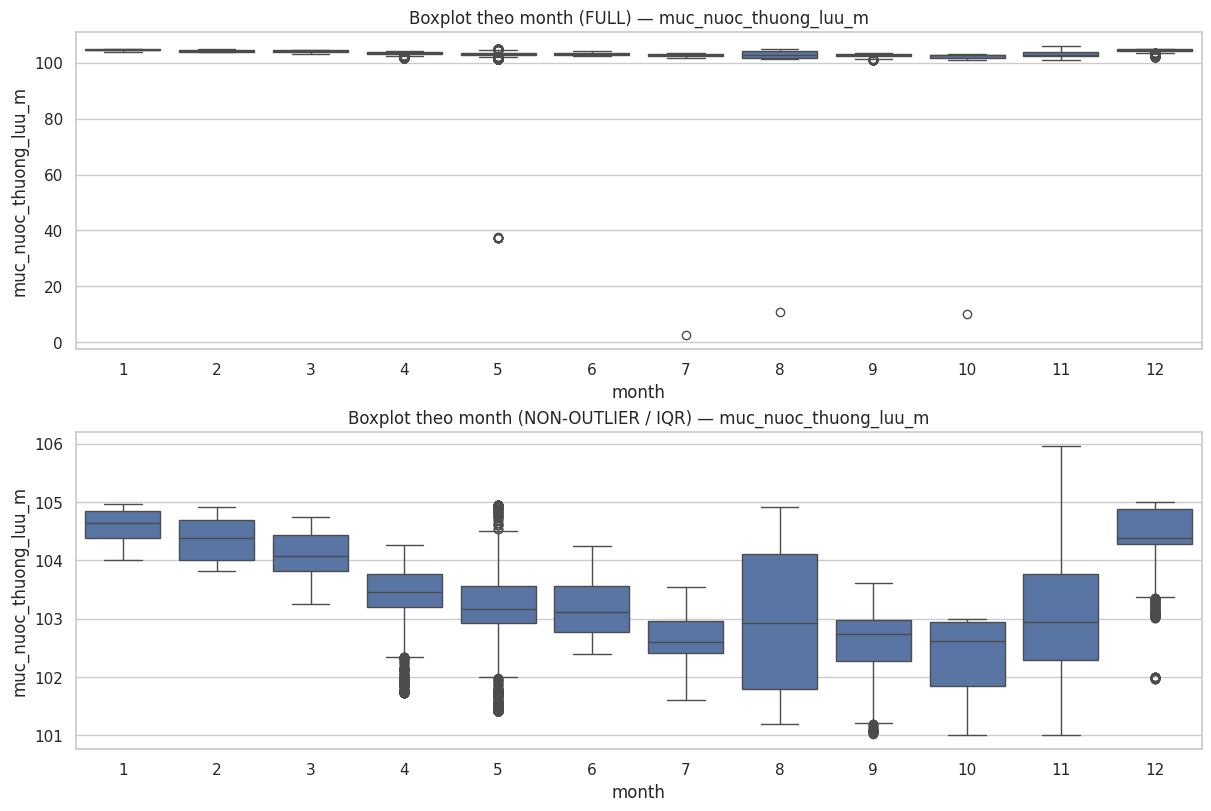

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_box_month_full_vs_inlier.png


In [ ]:
# Cell X: Boxplot theo month (FULL) + Boxplot theo month (NON-OUTLIER theo IQR) — 2x1 matrix
target = "muc_nuoc_thuong_luu_m"

df_b = df2.copy()  # df2 đã có month (và thường là đã parse datetime)
order_month = list(range(1, 13))

# --- Tính IQR bounds trên toàn bộ dữ liệu (global) ---
s = df_b[target].dropna().astype(float)
if s.empty:
    print(f"{target}: không có dữ liệu sau khi clean. Bỏ qua.")
else:
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    # --- Tạo df non-outlier ---
    df_inlier = df_b[df_b[target].astype(float).between(LB, UB)].copy()

    # Output folder
    out_dir = out_dir if 'out_dir' in globals() else ".././TrucQuanDonBien/SongBaHa"
    os.makedirs(out_dir, exist_ok=True)

    print(f"{target} IQR bounds: LB={LB:.2f}, UB={UB:.2f}")
    print(f"Full n={len(df_b):,} | Inlier n={len(df_inlier):,} | Outlier n={(len(df_b)-len(df_inlier)):,}")

    # --- Plot 2x1: FULL vs INLIER ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
    axes[0].set_title(f'Boxplot theo month (FULL) — {target}')
    axes[0].set_xlabel('month')

    sns.boxplot(x='month', y=target, data=df_inlier, order=order_month, ax=axes[1])
    axes[1].set_title(f'Boxplot theo month (NON-OUTLIER / IQR) — {target}')
    axes[1].set_xlabel('month')

    fn = os.path.join(out_dir, f"{target}_box_month_full_vs_inlier.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print("Saved:", fn)

Dưới đây là phân tích “có căn cứ” để giải thích vì sao cột `muc_nuoc_thuong_luu_m` của **Hồ Hòa Bình** hay xuất hiện giá trị rất thấp vào **tháng 6** – và gợi ý cách xử lý outlier theo đúng bản chất dữ liệu.

1) Nguyên do chính (mang tính hệ thống, không phải lỗi đo)

**Quy trình vận hành liên hồ trên lưu vực sông Hồng** quy định rất rõ cách điều tiết mức nước của Hồ Hòa Bình quanh **tháng 6**:

* **Từ 01–14/6** (vẫn trong “mùa cạn”): Hòa Bình **phải xả liên tục tối thiểu 214 m³/s** về hạ du. Với điều kiện dòng chảy về hồ yếu, việc giữ nhịp xả tối thiểu này sẽ **kéo mực nước hồ xuống**. ([THƯ VIỆN PHÁP LUẬT][1])
* **Từ 15/6–19/7** (bắt đầu “lũ sớm”): Hòa Bình **phải duy trì mực nước không vượt “mực nước cao nhất trước lũ” = 105,0 m** (Bảng 1). Nghĩa là trước cao điểm mùa lũ, hồ **được chủ động hạ thấp** để dành dung tích chống lũ. ([THƯ VIỆN PHÁP LUẬT][1])
* **Trước 26/6 – cắt lũ tiểu mãn**: nếu có lũ tiểu mãn, Hòa Bình **được dùng dung tích đến 107 m** để cắt lũ, và khi lưu lượng giảm sẽ **đưa dần về 105 m**. ([THƯ VIỆN PHÁP LUẬT][1])
* (Để bạn hình dung thêm bối cảnh): sang **20/7–21/8 (lũ chính vụ)**, ngưỡng “mực nước cao nhất trước lũ” còn nghiêm ngặt hơn, **101,0 m** (Bảng 2); và **từ 16/9** hồ mới **được phép tích dần lên mực nước dâng bình thường 117 m**. ([THƯ VIỆN PHÁP LUẬT][1])

=> Do vậy, **mức nước tháng 6 thấp là chủ đích vận hành** (để tạo dung tích phòng lũ), **không phải bất thường của cảm biến**. Những điểm “rất thấp” bạn thấy trong tháng 6 thường là **điểm phù hợp quy trình**, đặc biệt quanh mốc **15/6**.

2) Vai trò của lượng mưa 2022–2025 (bối cảnh hỗ trợ)

* **Năm 2023**: EVN báo **lưu lượng về các hồ thủy điện miền Bắc tháng 4–5 rất kém** do tác động El Niño. Nếu đầu mùa mưa đến muộn/yếu, **mực nước đầu tháng 6 sẽ bắt đầu từ nền thấp** → càng dễ rơi vào “vùng thấp” khi phải hạ mực theo quy trình trước lũ. ([EVN][2])
* **Chính xác từng con số thiếu hụt mưa theo tháng cho riêng lưu vực sông Đà/Hòa Bình giai đoạn 01/2022–10/2025**: **không biết** (chưa có chuỗi mưa không gian–thời gian chi tiết cho lưu vực trong tay). Tuy nhiên, bối cảnh ENSO 2023–đầu 2024 (El Niño) đã được các cơ quan khí tượng quốc tế/Việt Nam nêu, hàm ý **nguy cơ ít mưa – dòng chảy kém** giai đoạn đầu mùa mưa. ([World Meteorological Organization][3])

> Tóm lại: **tháng 6 thấp** chủ yếu do **quy định hạ mực nước trước lũ**; **thiếu mưa/ít dòng chảy** (ví dụ 2023) làm **mức độ thấp rõ rệt hơn**, nhưng **yếu tố quyết định** vẫn là **quy trình vận hành**.

3) Hàm ý xử lý “outlier” đúng bản chất

Vì các giá trị “rất thấp” trong tháng 6 nhiều khả năng **hợp lệ theo quy trình**, bạn **không nên** coi chúng là “lỗi” để xóa/cắt mù. Nên dùng **các phương án theo chế độ (regime-aware)**:

1. **Phân vùng theo chế độ vận hành**

   * Tạo cờ `is_lu_som` cho **15/6–19/7**, `is_pre_lu_som` cho **01–14/6**, `is_lu_chinh_vu` cho **20/7–21/8**.
   * Phân tích/chuẩn hóa **theo từng chế độ** thay vì toàn bộ phân phối năm. Điều này tránh gán nhãn “outlier” cho các điểm thấp **do quy trình**.

2. **Ngưỡng kỹ thuật làm “rào cứng”**

   * Dưới **mực nước chết 80 m** (theo Quy trình) là **không khả thi** về mặt kỹ thuật của hồ → nếu dữ liệu < 80 m, đó mới là **outlier thực sự** (sai nhập/đo đạc). ([THƯ VIỆN PHÁP LUẬT][1])
   * Trong **15/6–19/7**, mức **>~112–115 m** cũng khó xuất hiện nếu không có lệnh đặc biệt, do ngưỡng 105 m (lũ sớm) & 107 m (tiểu mãn). Các điểm quá cao trong giai đoạn này đáng để **rà soát** theo nhật ký vận hành.

3. **Phát hiện outlier theo tháng/chế độ**

   * Dùng **IQR/quantile** theo **(tháng, hoặc cờ chế độ)** để cắt đuôi dưới/thay thế (winsorize) thay vì dùng ngưỡng cho cả năm.
   * Với mô hình dự báo, cân nhắc **robust scaler**, **Huber loss** (thay vì MSE) để giảm độ nhạy với các đuôi thấp “hợp lệ”.

4. **Bổ sung biến giải thích**

   * Thêm đặc trưng: `season_phase` (pre-lũ sớm/lũ sớm/lũ chính vụ), `policy_cap` (105/101 m), `min_discharge_flag` (01–14/6), cùng biến mưa/lưu lượng đến hồ (nếu có) → mô hình sẽ **hiểu** vì sao tháng 6 thấp và **không coi** đó là nhiễu.

---

## Gợi ý kiểm chứng nhanh trên dữ liệu của bạn

* Kiểm tra median/percentile theo **tháng**: median tháng 6 sẽ thấp hơn rõ rệt so với 9–12/2022–2025.
* Zoom vào **các ngày quanh 15/6**: mức nước có xu hướng giảm/neo thấp tương ứng mốc bước sang “lũ sớm”.
* Rà **giá trị < 80 m**: nếu có → **sai** (loại/sửa). ([THƯ VIỆN PHÁP LUẬT][1])

Nếu bạn muốn, mình sẽ viết ngay đoạn code “regime-aware outlier” (theo tháng & theo cờ vận hành) để chạy trực tiếp trên `df`.

[1]: https://thuvienphapluat.vn/van-ban/Linh-vuc-khac/Quyet-dinh-740-QD-TTg-2019-ve-Quy-trinh-van-hanh-lien-ho-chua-tren-luu-vuc-song-Hong-416836.aspx "
	Quyết định 740/QĐ-TTg 2019 về Quy trình vận hành liên hồ chứa trên lưu vực sông Hồng
"
[2]: https://evn.com.vn/d6/news/Tinh-hinh-hoat-dong-6-thang-dau-nam-2023-va-muc-tieu-nhiem-vu-cong-tac-thang-72023-66-142-121116.aspx?utm_source=chatgpt.com "Tình hình hoạt động 6 tháng đầu năm 2023 và mục ... - EVN"
[3]: https://wmo.int/publication-series/el-ninola-nina-update-may-2024?utm_source=chatgpt.com "El Niño/La Niña Update (May 2024) - wmo.int"


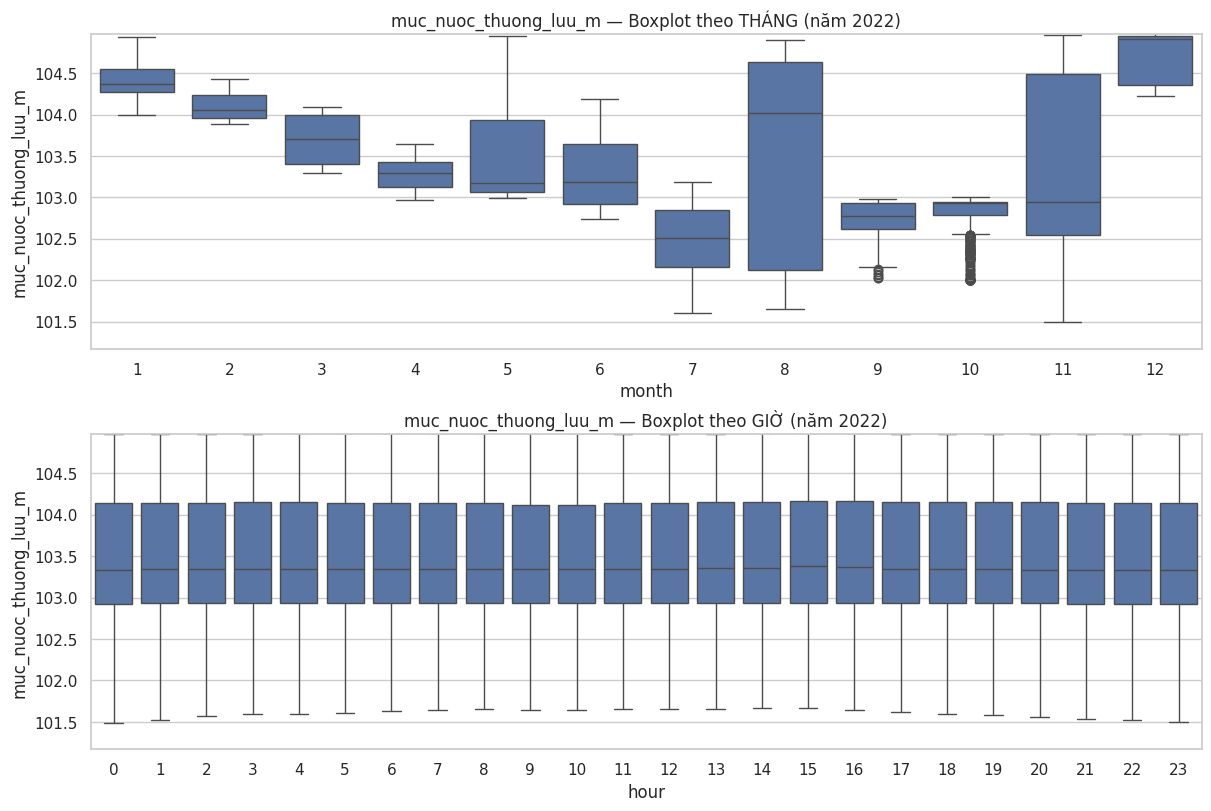

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_box_month_hour_2022.png


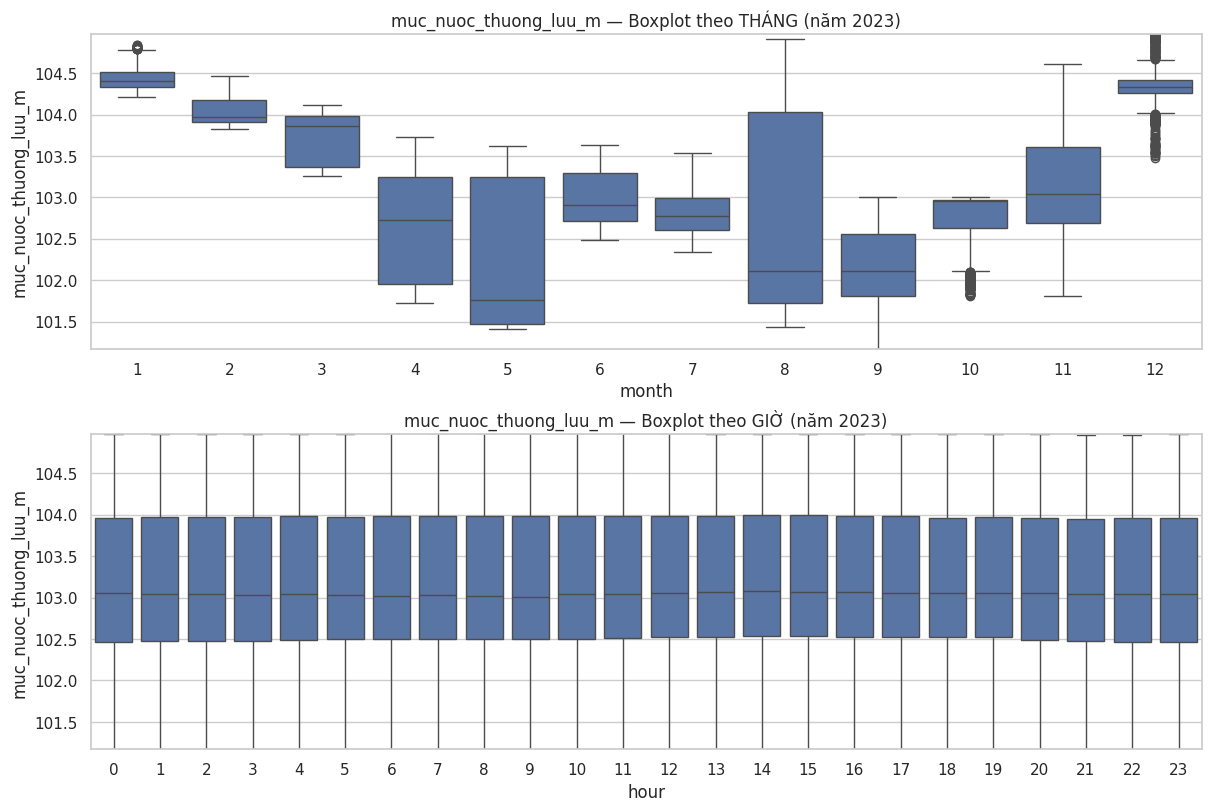

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_box_month_hour_2023.png


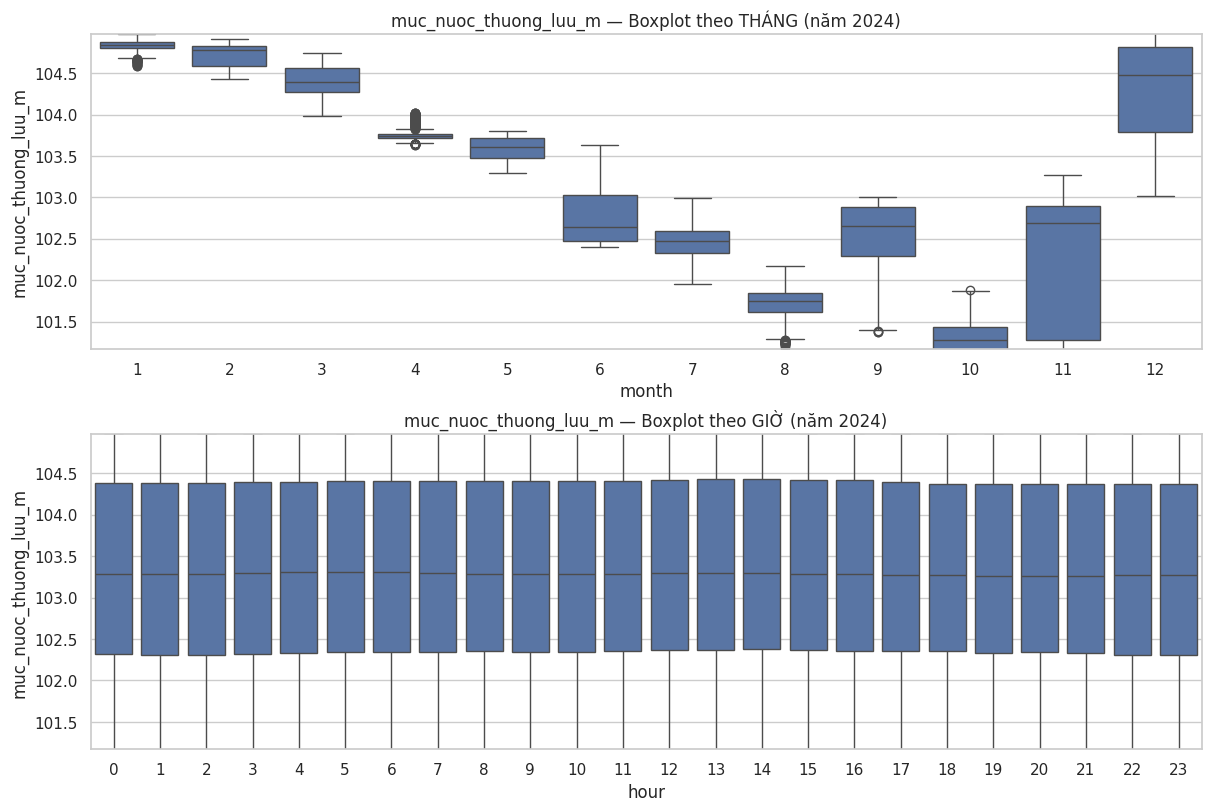

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_box_month_hour_2024.png


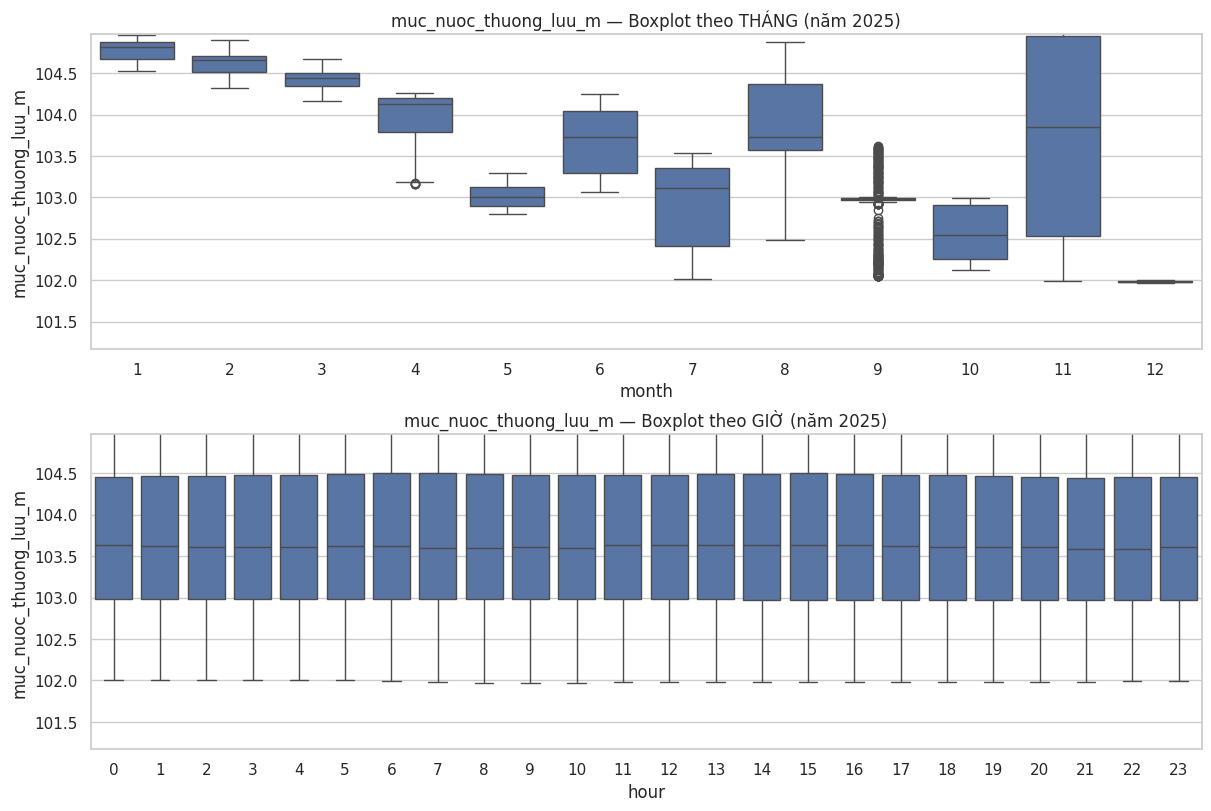

Saved: .././TrucQuanDonBien/SongBaHa/muc_nuoc_thuong_luu_m_box_month_hour_2025.png


In [22]:
# ==== Chuẩn bị ====
df_b = df2.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)


### Lưu lượng đến hồ (m3/s) trên từng thời điểm


In [23]:
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem').reset_index(drop=True)
# chọn biến
target = 'luu_luong_den_ho_m3_s'
df[target] = pd.to_numeric(df[target].astype(str).str.replace(r'\s+','', regex=True).str.replace(',',''), errors='coerce')

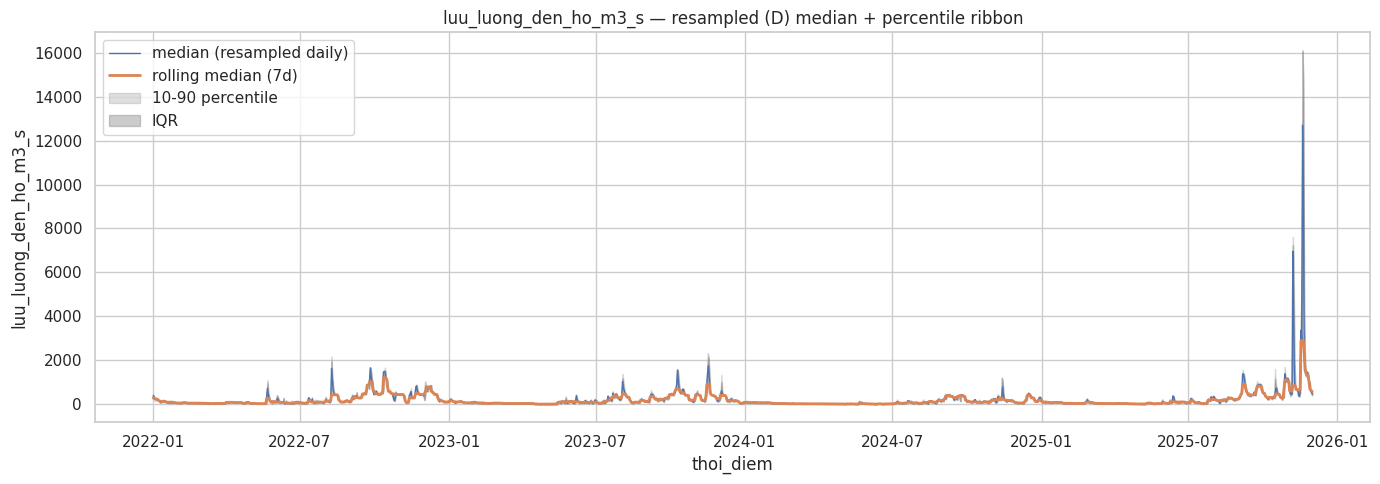

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_resampled_trend_daily.png


In [24]:
# Cell 3 (bản sửa): Resampled trend + percentile ribbon theo NGÀY ('D')
# Cố định freq='D' để mỗi ngày gom ~8 điểm -> P10/P25/P75/P90 & IQR hiện rõ

# Bảo đảm cột thời gian ở dạng datetime và đã sort
df['thoi_diem'] = pd.to_datetime(df['thoi_diem'], errors='coerce')
df = df.sort_values('thoi_diem')

freq = 'D'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<  CHỈNH TẠI ĐÂY

series = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .agg(['count', 'median', 'mean'])
)

# percentiles per resample (theo NGÀY)
agg_pct = (
    df.set_index('thoi_diem')[target]
      .resample(freq)
      .apply(lambda x: np.percentile(x.dropna(), [10, 25, 75, 90]) if len(x.dropna()) > 0 else [np.nan]*4)
)
pct_df = pd.DataFrame(agg_pct.tolist(), index=agg_pct.index, columns=['p10','p25','p75','p90'])

summary = pd.concat([series, pct_df], axis=1).dropna(subset=['median'])

# rolling median cho daily: 7 ngày
window = 7
summary['roll_median'] = summary['median'].rolling(window=window, min_periods=1, center=True).median()

plt.figure(figsize=(14,5))
plt.plot(summary.index, summary['median'], label='median (resampled daily)', linewidth=1)
plt.plot(summary.index, summary['roll_median'], label=f'rolling median ({window}d)', linewidth=2)
plt.fill_between(summary.index, summary['p10'], summary['p90'], color='grey', alpha=0.25, label='10-90 percentile')
plt.fill_between(summary.index, summary['p25'], summary['p75'], color='grey', alpha=0.40, label='IQR')
plt.legend()
plt.xlabel('thoi_diem'); plt.ylabel(target)
plt.title(f'{target} — resampled ({freq}) median + percentile ribbon')
plt.tight_layout()

# Lưu ảnh
if 'out_dir' not in globals():
    out_dir = ".././TrucQuanDaBien/SongBaHa"
import os
os.makedirs(out_dir, exist_ok=True)
fn = os.path.join(out_dir, f"{target}_resampled_trend_daily.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


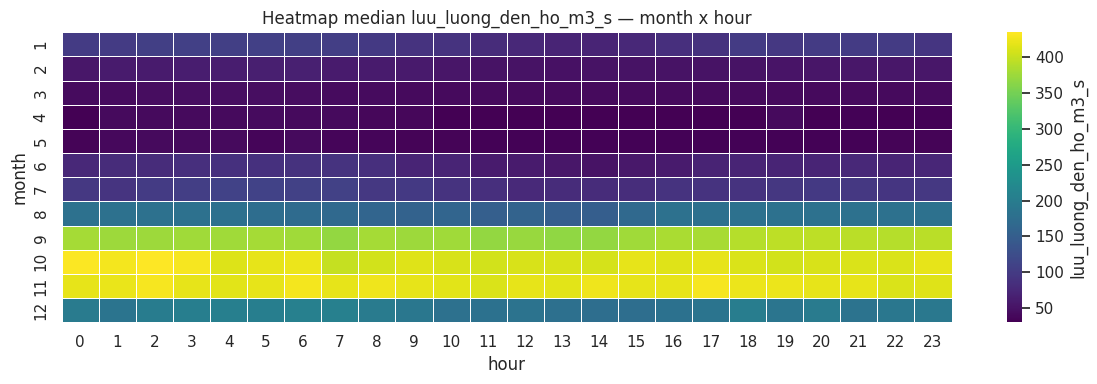

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_month_hour_heatmap.png


In [25]:
# Cell 4: Heatmap month x hour (muốn pattern theo giờ trong năm) — gọn, dễ đọc (12x24)
df2 = df.dropna(subset=['thoi_diem', target]).copy()
df2['month'] = df2['thoi_diem'].dt.month
df2['hour'] = df2['thoi_diem'].dt.hour
pivot = df2.pivot_table(index='month', columns='hour', values=target, aggfunc='median')  # median robust
plt.figure(figsize=(12,4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': target}, linewidths=0.5)
plt.title(f'Heatmap median {target} — month x hour')
plt.ylabel('month'); plt.xlabel('hour')
plt.tight_layout()
fn = os.path.join(out_dir, f"{target}_month_hour_heatmap.png")
plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


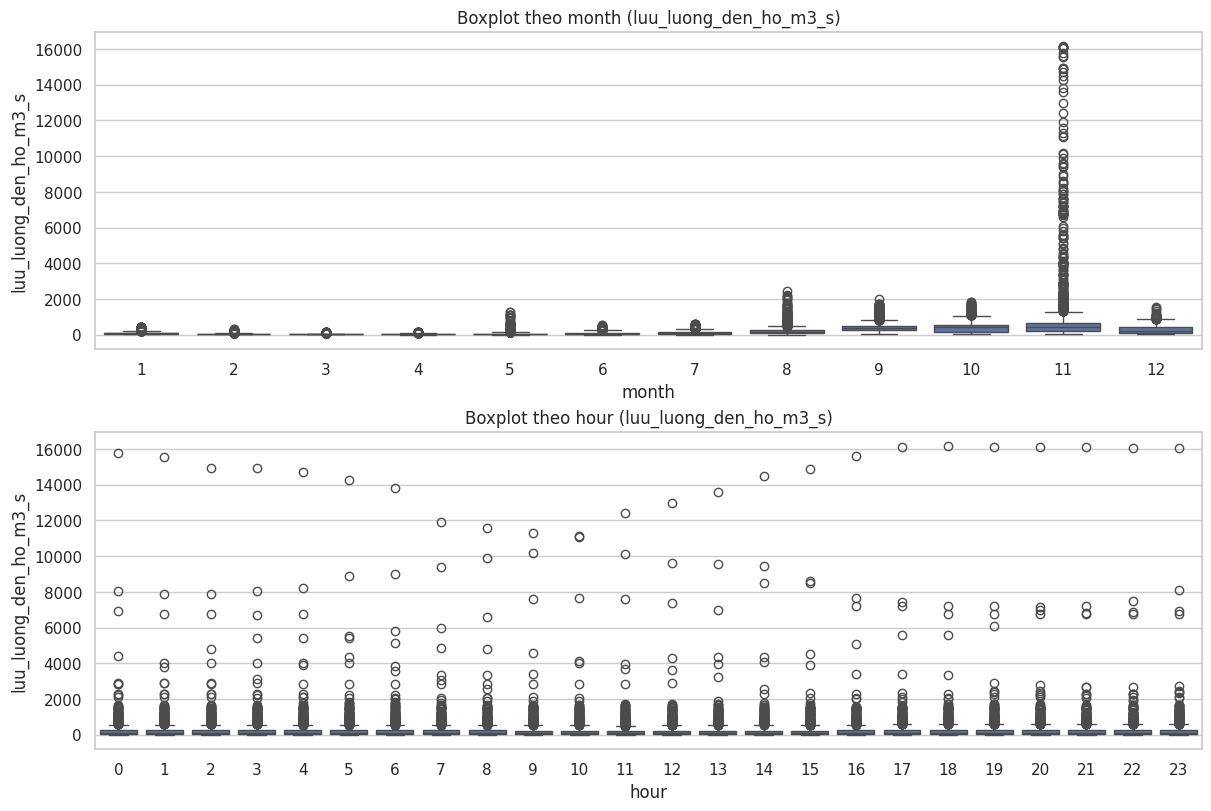

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_box_month_hour.png


In [26]:
# Cell 5: Boxplot by month (12 boxes) + Boxplot by hour (24 boxes) — 2x1 matrix, đơn giản, tổng quát
df_b = df2.copy()
order_month = list(range(1,13))
order_hour = list(range(0,24))

fig, axes = plt.subplots(2,1, figsize=(12,8), constrained_layout=True)
sns.boxplot(x='month', y=target, data=df_b, order=order_month, ax=axes[0])
axes[0].set_title(f'Boxplot theo month ({target})'); axes[0].set_xlabel('month')

sns.boxplot(x='hour', y=target, data=df_b, order=order_hour, ax=axes[1])
axes[1].set_title(f'Boxplot theo hour ({target})'); axes[1].set_xlabel('hour')

fn = os.path.join(out_dir, f"{target}_box_month_hour.png")
fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", fn)


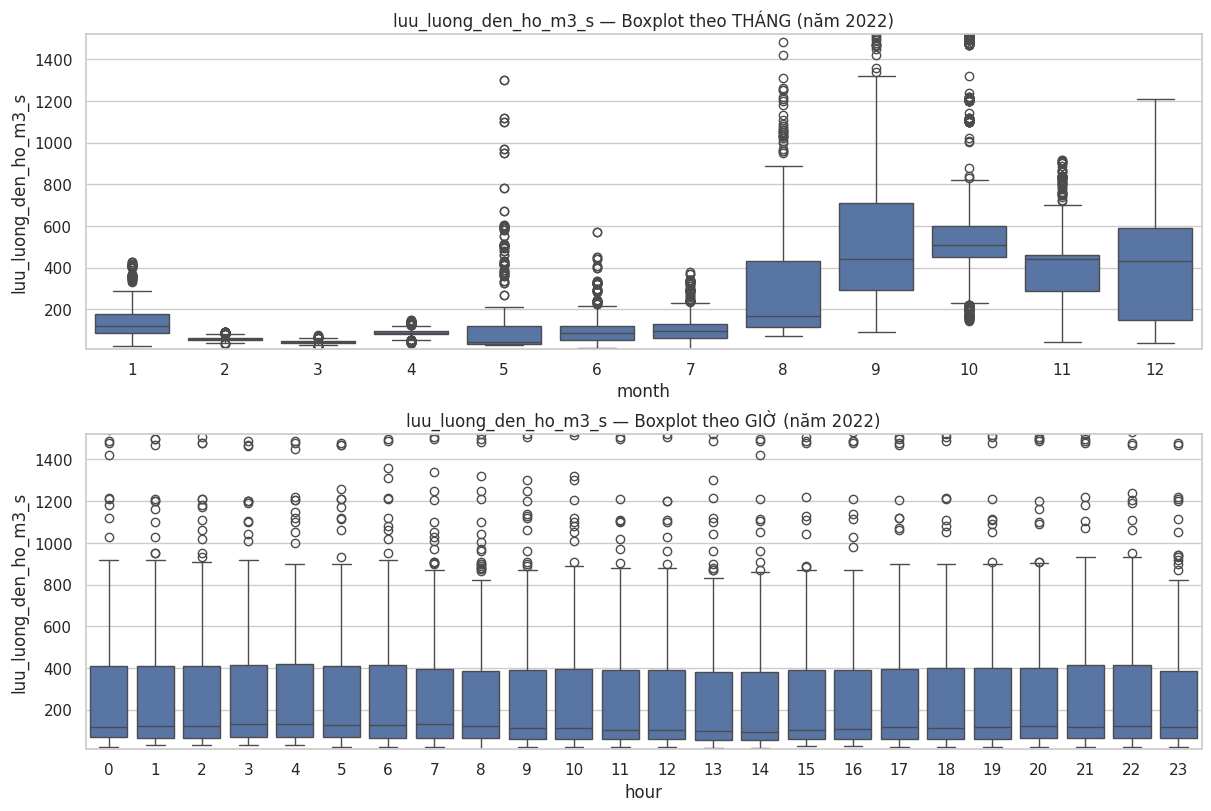

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_box_month_hour_2022.png


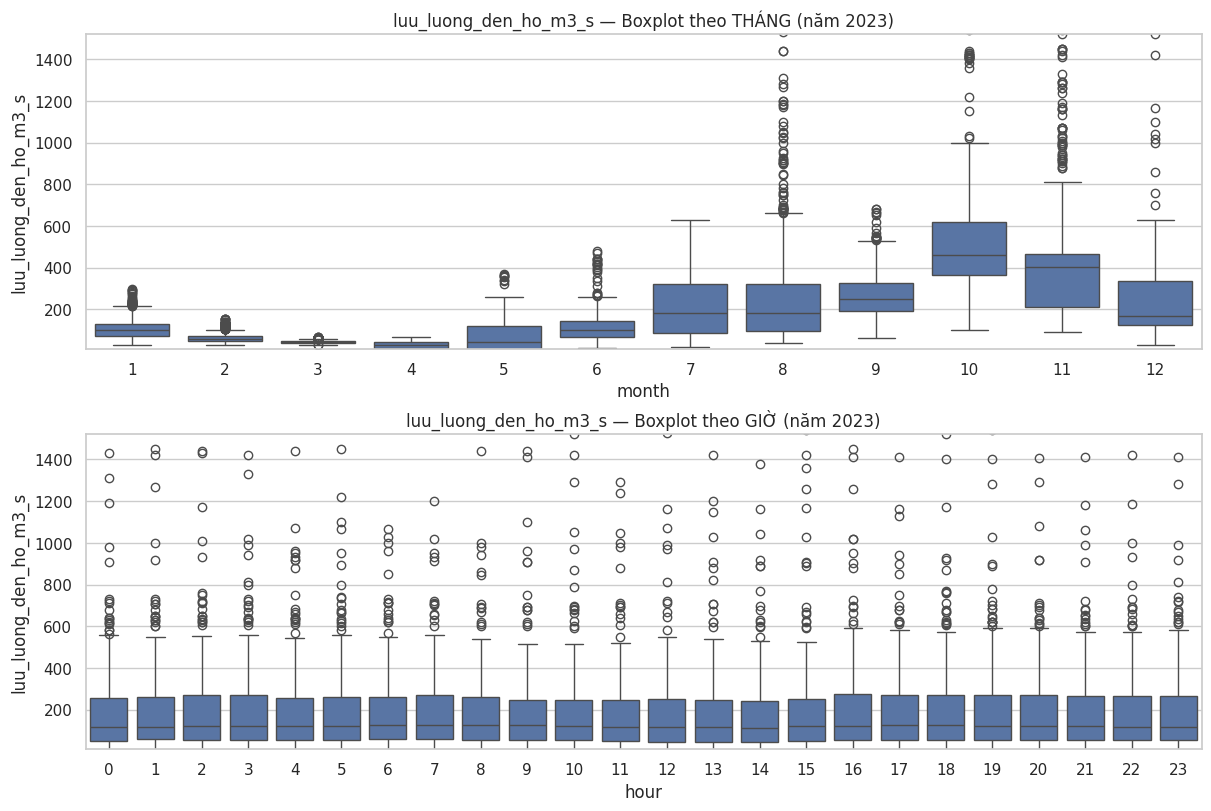

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_box_month_hour_2023.png


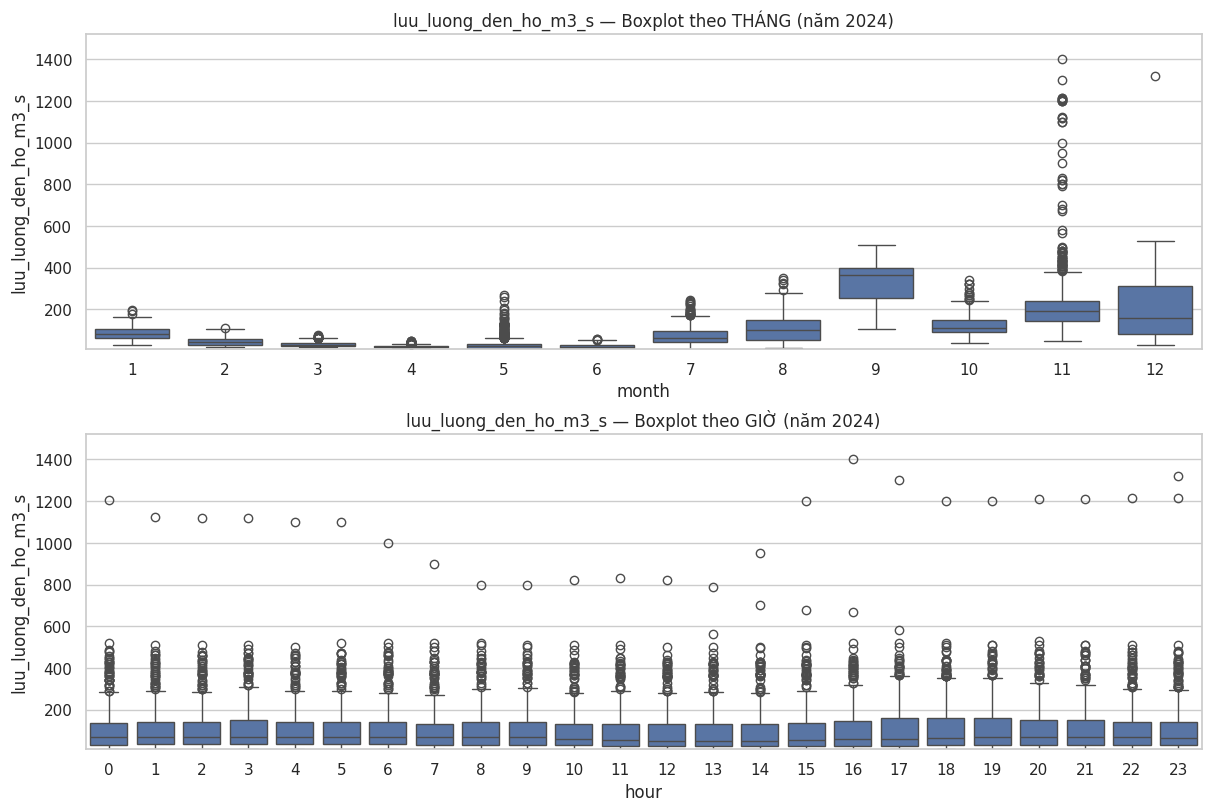

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_box_month_hour_2024.png


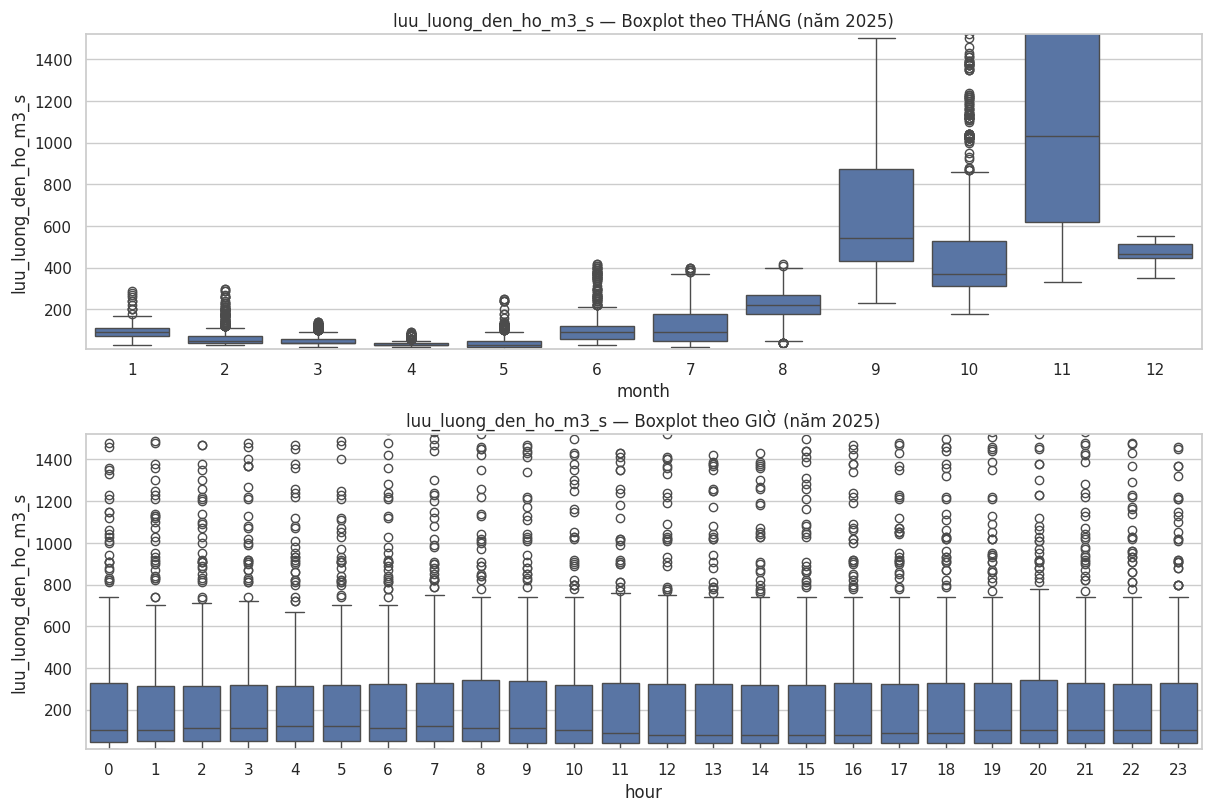

Saved: .././TrucQuanDonBien/SongBaHa/luu_luong_den_ho_m3_s_box_month_hour_2025.png


In [27]:
# ==== Chuẩn bị ====
df_b = df2.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)